# PS-S6E02: NN — Tabular ResNet (Embeddings)

This notebook tackles the [**Playground Series – Season 6, Episode 2: Predicting Heart Disease**](https://www.kaggle.com/competitions/playground-series-s6e2), a competition focused on predicting if a patient has heart disease, based on features describing the patient's demographics and selected health metrics.

**Task**
*   Binary classification: predict **presence vs absence of heart disease**
*   Target column: Heart Disease
*   Evaluation metric: **ROC AUC**
*   Submission format: probability of disease presence per row
**Model**
*   Tabular neural network with:
    *   Numeric features
    *   Embedded categorical features
    *   Residual MLP backbone
*   Trained using stratified cross-validation
*   Final predictions are averaged across folds
  
This notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S06E01: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e01-eda).

## Install Needed Packages

In [1]:
!pip install torch torchvision torchaudio


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import gc
import sys
import copy
import math
import random
import warnings

# --- Third-party
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e02_feature_engineering import FeatureFactory
from ps_s06e02_model_visualizer import ModelVisualizer
from ps_s06e02_experiment_setup import ExperimentSetup

warnings.filterwarnings('ignore')

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [3]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'Heart Disease'

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

### Dataset Description
The dataset contains clinical and diagnostic measurements commonly used in heart disease screening.

**Key characteristics**
*   Mixed numeric and categorical inputs
*   Moderate dataset size (well-suited for NN + CV)
*   Target labels provided as strings:
    *   `Presence`
    *   `Absence`
  
**Target encoding**
*   `Presence` → 1
*   `Absence` → 0

In [4]:
training_df = helper.read_dataset('training')

TRAINING DATASET

   id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   0   58    1                4  152          239             0            0   
1   1   52    1                1  125          325             0            2   
2   2   56    0                2  160          188             0            2   
3   3   44    0                3  134          229             0            2   
4   4   58    1                4  140          234             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     158                1          3.600            2   
1     171                0          0.000            1   
2     151                0          0.000            1   
3     150                0          1.000            2   
4     125                1          3.800            2   

   Number of vessels fluro  Thallium Heart Disease  
0                        2         7      Presence  
1                        0         3    

## Read and Examine the Test Dataset

In [5]:
test_df = helper.read_dataset('test')

TEST DATASET

       id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  \
0  630000   58    1                3  120          288             0   
1  630001   55    0                2  120          209             0   
2  630002   54    1                4  120          268             0   
3  630003   44    0                3  112          177             0   
4  630004   43    1                1  138          267             0   

   EKG results  Max HR  Exercise angina  ST depression  Slope of ST  \
0            2     145                1          0.800            2   
1            0     172                0          0.000            1   
2            0     150                1          0.000            2   
3            0     168                0          0.900            1   
4            0     163                0          1.800            2   

   Number of vessels fluro  Thallium  
0                        3         3  
1                        0         3  
2        

## Feature Engineering Strategy
Feature engineering is intentionally conservative to preserve signal for the neural network.

### Applied strategies
*   **Drop ID and target**
    *   id and Heart Disease are removed from the feature matrix
*   **Standard scaling**
    *   Applied to numeric features only
*   **Feature interactions**
    *   Simple numeric interactions to capture non-linear effects
  
### Not applied
*   **One-hot encoding**
    *   Categorical variables are passed to the model as integer codes
    *   Embeddings are learned directly by the network
*   **Target transformations**
    *   Binary labels are used directly (no scaling or clipping)
  
This setup avoids destroying ordinal information and allows the NN to learn category relationships via embeddings.

In [6]:
# Define which strategies to use for the CatBoost model here:
fe_strategies = [
    'drop_id',
    'one_hot_encoding',
    'numeric_transforms',
    'standard_scaling',  # Ensures all features are on a comparable scale
]

In [7]:
print('Performing initial feature engineering.')

# Get a clean 0/1 label vector for AUC + BCE.
y = (
    training_df[TARGET]
    .map({'Absence': 0, 'Presence': 1})
    .astype(np.int64)
)

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')

cat_features = feature_engineer.get_cat_features(X)
print(f'Cat features for NN embeddings ({len(cat_features)}): {cat_features}')

print(X.head())

Performing initial feature engineering.
Old Feature Count: 14
New Feature Count: 32
Cat features for NN embeddings (0): []
     Age     BP  Cholesterol  Max HR  ST depression  log1p_Cholesterol  \
0  0.468  1.436       -0.178   0.271          3.041             -0.112   
1 -0.259 -0.367        2.375   0.951         -0.755              2.117   
2  0.226  1.970       -1.693  -0.095         -0.755             -1.850   
3 -1.228  0.234       -0.475  -0.147          0.299             -0.421   
4  0.468  0.635       -0.327  -1.455          3.252             -0.265   

   ST_depression_is_zero  log1p_ST_depression  ST_by_MaxHR  Sex_0  Sex_1  \
0                 -1.000                2.299        2.618 -0.632  0.632   
1                  1.000               -0.852       -0.731 -0.632  0.632   
2                  1.000               -0.852       -0.731  1.583 -1.583   
3                 -1.000                0.579        0.249  1.583 -1.583   
4                 -1.000                2.387       

### Model Training: Neural Network Strategy (Binary Classification)

Model training is performed using **5-Fold Stratified Cross-Validation**, which is critical for stabilizing neural network performance on a binary classification task with class imbalance.

Neural networks are sensitive to random initialization, learning-rate schedules, and training duration. Cross-validation combined with early stopping provides a more reliable estimate of generalization performance and reduces the risk of overfitting.
1.  **Feature Scaling and Input Preparation**
    * **Numeric features** are standardized prior to training to ensure comparable scales across inputs.
    * **Categorical features** are passed as integer-encoded values and learned via embedding layers inside the model.
    * The target variable is encoded as:
        * `Presence → 1`
        * `Absense → 0`
    * Standardizing numeric inputs improves optimizer stability and convergence when training with gradient-based methods.
2.  **Stratified Cross-Validation**
    * Training uses **StratifiedKFold** to preserve class proportions in every fold.
    * This is especially important for ROC AUC evaluation, which can be sensitive to skewed validation splits.
    * Out-of-fold probability estimates are stored for unbiased evaluation and later blending.
3.  **Optimization Objective**
    * The model is trained using **Binary Cross-Entropy with Logits** (`BCEWithLogitsLoss`).
    * The network outputs raw logits; the sigmoid function is applied only during evaluation to produce probabilities.
    * Model performance is evaluated using **ROC AUC**, matching the competition’s leaderboard metric.
4.  **Adaptive Learning and Early Stopping**
To prevent overfitting and unnecessary training:
    * **ReduceLROnPlateau** lowers the learning rate when validation AUC plateaus.
    * **Early stopping** is applied based on validation AUC.
    * For each fold, the model weights corresponding to the best validation AUC are restored before inference.
  
This approach ensures that each fold contributes well-calibrated probability estimates rather than over-trained predictions.

In [8]:
def fit_nn_encoders(X_train: pd.DataFrame, X_ref: pd.DataFrame, cat_cols: list[str]):
    """
    Fit categorical mappings using X_train + X_ref (usually X_test) so test categories are known.
    Return mappings and numeric column list.
    """
    X_all = pd.concat([X_train[cat_cols], X_ref[cat_cols]], axis=0, ignore_index=True)

    cat_maps = {}
    cat_dims = []
    for c in cat_cols:
        s = X_all[c]
        
        # normalize to string tokens, treat NaN consistently
        s = s.astype(str).fillna("__nan__")
        uniq = pd.Index(s.unique())
        cat_maps[c] = {k: i for i, k in enumerate(uniq)}
        cat_dims.append(len(uniq))

    num_cols = [c for c in X_train.columns if c not in cat_cols]
    return {"cat_cols": cat_cols, "num_cols": num_cols, "cat_maps": cat_maps, "cat_dims": cat_dims}

def transform_with_encoders(X: pd.DataFrame, fitted):
    cat_cols = fitted["cat_cols"]
    num_cols = fitted["num_cols"]
    cat_maps = fitted["cat_maps"]

    # numeric
    X_num = X[num_cols].to_numpy(dtype=np.float32)

    # categorical: map unknown to 0 (or add an "__unk__" index if you prefer)
    X_cat = np.zeros((len(X), len(cat_cols)), dtype=np.int64)
    for j, c in enumerate(cat_cols):
        m = cat_maps[c]
        s = X[c].astype(str).fillna("__nan__")
        X_cat[:, j] = s.map(lambda v: m.get(v, 0)).to_numpy(dtype=np.int64)

    return X_num, X_cat


In [9]:
class ResNetBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super(ResNetBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, input_dim),
            nn.BatchNorm1d(input_dim)
        )
        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(x + self.block(x))


class TabularResNet(nn.Module):
    def __init__(self, num_dim, cat_dims, hidden_dim=512, dropout_rate=0.2, num_blocks=3):
        super(TabularResNet, self).__init__()
        
        # Embedding Layers for Categoricals
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_cats, emb_dim) 
            for num_cats, emb_dim in cat_dims
        ])
        
        # Calculate total input size after embeddings
        total_cat_dim = sum(emb_dim for _, emb_dim in cat_dims)
        combined_dim = num_dim + total_cat_dim
        
        # Input Projector
        self.input_layer = nn.Linear(combined_dim, hidden_dim)
        self.bn0 = nn.BatchNorm1d(hidden_dim)
        
        # Residual Blocks
        self.blocks = nn.ModuleList([
            ResNetBlock(hidden_dim, hidden_dim, dropout_rate) 
            for _ in range(num_blocks)
        ])
        
        # Output Head
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, x_num, x_cat):
        # x_num: [batch_size, num_dim]
        # x_cat: [batch_size, num_cats] (Integers)
        
        # Process Embeddings
        embedded_cats = []
        for i, emb_layer in enumerate(self.embeddings):
            # x_cat[:, i] grabs the column for the i-th categorical var
            embedded_cats.append(emb_layer(x_cat[:, i]))
        
        # Concatenate all embeddings + numericals
        # [batch, cat_dim_1] + [batch, cat_dim_2] ... + [batch, num_dim]
        x = torch.cat(embedded_cats + [x_num], dim=1)
        
        # Pass through network
        x = self.input_layer(x)
        x = self.bn0(x)
        
        for block in self.blocks:
            x = block(x)
            
        return self.output_head(x)

In [10]:
# Dataset Class to handle Dual Inputs
class TabularDataset(torch.utils.data.Dataset):
    def __init__(self, x_num, x_cat, y=None):
        self.x_num = torch.FloatTensor(x_num)
        self.x_cat = torch.LongTensor(x_cat)
        self.y = torch.FloatTensor(y).reshape(-1, 1) if y is not None else None
        
    def __len__(self):
        return len(self.x_num)
        
    def __getitem__(self, idx):
        if self.y is not None:
            return self.x_num[idx], self.x_cat[idx], self.y[idx]
        return self.x_num[idx], self.x_cat[idx]

### Evaluation Metric
**Primary metric: ROC AUC**
*   Computed on:
    *   Each validation fold
    *   Final out-of-fold predictions
*   Uses **predicted probabilities**, not hard labels
  
**Why AUC**
*   Threshold-independent
*   Robust to class imbalance
*   Matches Kaggle leaderboard scoring

In [11]:
# Setup Device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {device}')

# Hyperparameters
BATCH_SIZE = 256
EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Training Setup
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

# y must align with training_df rows
y = training_df[TARGET].map({'Absence': 0, 'Presence': 1}).astype(np.int64).values

oof_probs = np.zeros(len(training_df), dtype=np.float32)
test_probs = np.zeros(len(test_df), dtype=np.float32)
history = {'train_loss': [], 'val_auc': [], 'lrs': []}
scores = []

print(f'Starting Training with {n_folds} folds...')

for fold, (train_idx, val_idx) in enumerate(skf.split(training_df, y), 1):
    print(f'\n=== Fold {fold}/{n_folds} ===')

    # Slice the pre-prepared numpy arrays
    X_train_df = training_df.iloc[train_idx].copy()
    X_val_df   = training_df.iloc[val_idx].copy()
    
    y_train = y[train_idx]
    y_val   = y[val_idx]
    
    # Fit FE on train fold only
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed + fold)

    X_tr_full = fe_fold.fit_transform(X_train_df)
    X_va_full = fe_fold.transform(X_val_df)
    X_te_full = fe_fold.transform(test_df)

    X_tr = X_tr_full.drop(columns=[TARGET], errors='ignore')
    X_va = X_va_full.drop(columns=[TARGET], errors='ignore')
    X_te = X_te_full.drop(columns=[TARGET], errors='ignore')

    # Use FE to define categorical embedding columns (includes bins/crosses)
    cat_features = fe_fold.get_cat_features(X_tr)

    fitted = fit_nn_encoders(X_tr, X_te, cat_features)
    
    Xtr_num_np, Xtr_cat_np = transform_with_encoders(X_tr, fitted)
    Xva_num_np, Xva_cat_np = transform_with_encoders(X_va, fitted)
    Xte_num_np, Xte_cat_np = transform_with_encoders(X_te, fitted)
    
    # TabularResNet expects [(num_cats, emb_dim), ...]
    cat_dims = [(n, min(16, int(np.ceil(np.sqrt(n))))) for n in fitted["cat_dims"]]
    num_dim = Xtr_num_np.shape[1]

    # Build fold tensors
    Xtr_num = torch.tensor(Xtr_num_np, dtype=torch.float32)
    Xtr_cat = torch.tensor(Xtr_cat_np, dtype=torch.long)
    ytr_t   = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    Xva_num = torch.tensor(Xva_num_np, dtype=torch.float32)
    Xva_cat = torch.tensor(Xva_cat_np, dtype=torch.long)
    yva_t   = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    train_ds = TensorDataset(Xtr_num, Xtr_cat, ytr_t)
    val_ds   = TensorDataset(Xva_num, Xva_cat, yva_t)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    model = TabularResNet(
        num_dim=num_dim,
        cat_dims=cat_dims,
        hidden_dim=256,
        num_blocks=4,
        dropout_rate=0.2,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.BCEWithLogitsLoss()

    # SCHEDULER: Using CosineAnnealingWarmRestarts
    # T_0=10 means it resets LR every 10 epochs
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

    # Early Stopping / Best Model Logic
    best_val_auc = -1.0
    best_state = None
    best_model_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0
    ES_PATIENCE = 15
    
    progress_bar = tqdm(range(EPOCHS), desc=f'Fold {fold}', leave=True)

    # Outer Loop: Epochs
    for epoch in progress_bar:
        model.train()
        running_loss = 0.0

        for batch_num, batch_cat, batch_y in train_loader:
            batch_num, batch_cat, batch_y = batch_num.to(device), batch_cat.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            logits = model(batch_num, batch_cat)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()

        # Step Scheduler (Cosine updates every batch usually, but epoch is fine for tabular)
        scheduler.step()
        
        # Validation Check (End of Epoch)
        model.eval()

        with torch.no_grad():
            val_logits = model(
                Xva_num.to(device),
                Xva_cat.to(device)
            ).detach().cpu().numpy().ravel()
        
            val_prob = 1.0 / (1.0 + np.exp(-val_logits))
            val_auc = roc_auc_score(y_val, val_prob)

        history['train_loss'].append(running_loss / len(train_loader))
        history['val_auc'].append(val_auc)
        history['lrs'].append(optimizer.param_groups[0]['lr'])

        # Save Best Model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        # Update Progress Bar Text
        progress_bar.set_postfix({
            'loss': f'{running_loss/len(train_loader):.4f}',
            'val_auc': f'{val_auc:.4f}',
            'best': f'{best_val_auc:.4f}'
        })
        
        if patience_counter >= ES_PATIENCE:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    # Final Inference for Fold using Best Weights
    model.load_state_dict(best_model_weights)
    model.eval()

    with torch.no_grad():
        # val preds
        logits_va = model(Xva_num.to(device), Xva_cat.to(device)).cpu().numpy().reshape(-1)
        probs_va = 1 / (1 + np.exp(-logits_va))
        oof_probs[val_idx] = probs_va.astype(np.float32)

        # test preds for this fold
        Xte_num = torch.tensor(Xte_num_np, dtype=torch.float32)
        Xte_cat = torch.tensor(Xte_cat_np, dtype=torch.long)
        logits_te = model(Xte_num.to(device), Xte_cat.to(device)).cpu().numpy().reshape(-1)
        probs_te = 1 / (1 + np.exp(-logits_te))
        test_probs += (probs_te / n_folds).astype(np.float32)

    print(f'Fold {fold+1} Best AUC: {best_val_auc:.5f}')
    scores.append(best_val_auc)

    del model, optimizer, train_loader, val_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
print(f'\nOverall CV AUC: {np.mean(scores):.5f}')        

Training on: cuda
Starting Training with 5 folds...

=== Fold 1/5 ===


Fold 1:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 42
Fold 2 Best AUC: 0.95396

=== Fold 2/5 ===


Fold 2:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 35
Fold 3 Best AUC: 0.95325

=== Fold 3/5 ===


...

  Early stopping at epoch 25
Fold 4 Best AUC: 0.95281

=== Fold 4/5 ===


Fold 4:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 35
Fold 5 Best AUC: 0.95378

=== Fold 5/5 ===


Fold 5:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 31
Fold 6 Best AUC: 0.95265

Overall CV AUC: 0.95329


## Visualizing Model Performance
The following diagnostics are generated using out-of-fold predictions:
* ROC curve
* Training heartbeat
* Distribution mismatch
* Normalized confusion matrix (at 0.5 threshold)

<Figure size 800x600 with 0 Axes>

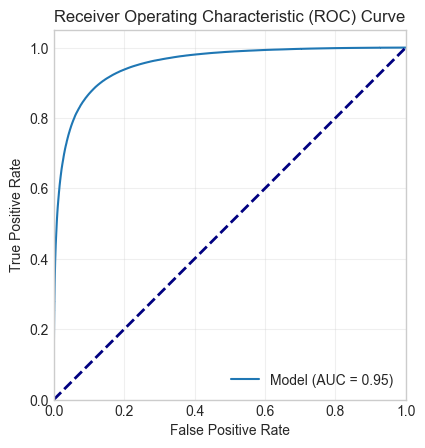

In [12]:
mviz = ModelVisualizer(model_name='Neural Network')

mviz.plot_roc_curve(y_true=y, y_score=oof_probs)

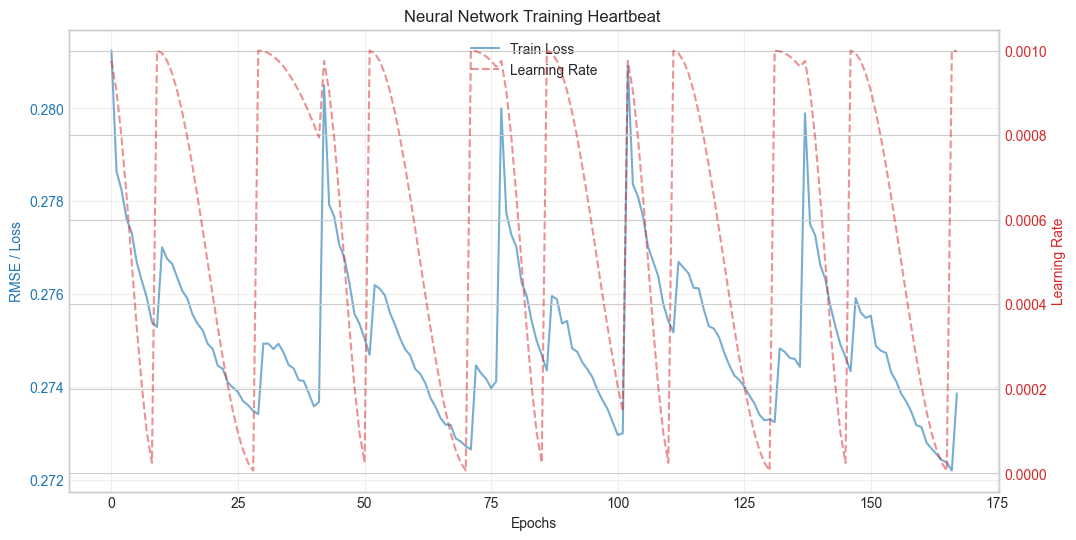

In [13]:
mviz.plot_training_heartbeat(history)

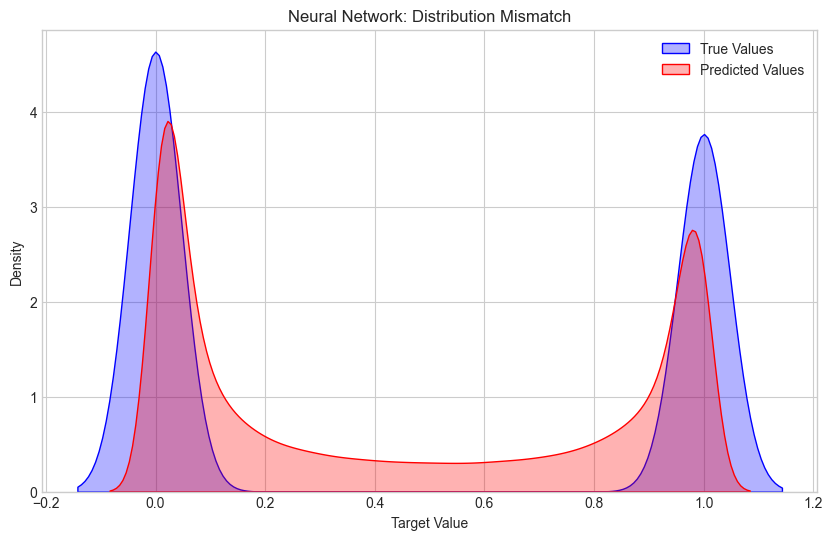

In [14]:
mviz.plot_distribution_mismatch(y_val, oof_probs) # Use the last fold's data

Normalized confusion matrix


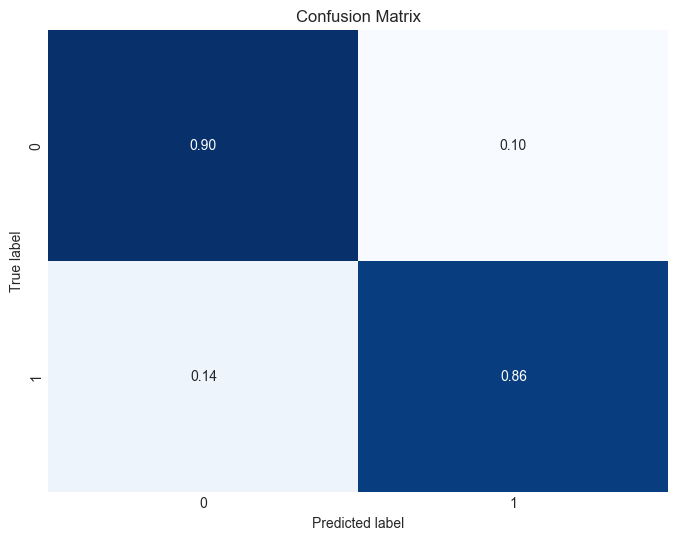

In [15]:
prob_label = (oof_probs >= 0.5).astype(int)
mviz.plot_confusion_matrix(y_true=y, y_pred=prob_label, classes=[0, 1], normalize=True)

## Prepare Submission

In [16]:
submission_df = helper.read_dataset('submission')
target_col = [c for c in submission_df.columns if c != 'id'][0]
submission_df[target_col] = test_probs

print('SAMPLE SUBMISSION')
print('=================')

print(submission_df.head(10))

SAMPLE SUBMISSION
       id  Heart Disease
0  630000          0.925
1  630001          0.004
2  630002          0.990
3  630003          0.002
4  630004          0.373
5  630005          0.986
6  630006          0.015
7  630007          0.673
8  630008          0.995
9  630009          0.009


In [17]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

Out-of-fold (OOF) **probability estimates** and averaged test-set **probability estimates**
are saved for downstream analysis and ensembling.

These files are used to:

- Compare model performance using OOF ROC AUC
- Analyze correlation and complementarity between models
- Serve as inputs to a separate blending notebook that combines model probabilities

Each file contains raw, un-thresholded probabilities, which is essential for
AUC-based evaluation and weighted blending techniques, including those described by
Tilii in *For the (recovering) blind blending addicts*:
https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787


In [18]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF probabilities and raw Test probabilities.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({
    'id': training_df['id'],
    'prob_nn_tabular_resnet': oof_probs,
    'target': y
})
oof_df.to_csv(f'{output_dir}/nn-tabular-resnet_oof_probs.csv', index=False)

test_prob_df = pd.DataFrame({
    'id': test_df['id'],
    'prob_nn_tabular_resnet': test_probs
})
test_prob_df.to_csv(f'{output_dir}/nn-tabular-resnet_test_probs.csv', index=False)

print(f'Saved for Blending: {output_dir}/nn-tabular-resnet_oof_probs.csv, {output_dir}/nn-tabular-resnet_test_probs.csv')

Saved for Blending: predictions/nn-tabular-resnet_oof_probs.csv, predictions/nn-tabular-resnet_test_probs.csv
